<a href="https://colab.research.google.com/github/rohkdev/ClimateModelingResearch/blob/main/Task%205%3A%20Percent%20Warm%20Nights%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Load cleaned daily temperature dataset
# ------------------------------------------------------------
df = pd.read_csv("clean_daily_temperatures.csv")
print("Initial rows loaded:", len(df))

# Format dates and create year/month columns (fixing the 'date' vs 'day' bug)
df["day"] = pd.to_datetime(df["day"])
df["month"] = df["day"].dt.month
df["year"] = df["day"].dt.year

# Ensure Fahrenheit columns exist (or convert on the fly if needed)
if "TMAX_F" not in df.columns:
    df["TMAX_F"] = (pd.to_numeric(df["TMAX"], errors="coerce") * 9/5) + 32
if "TMIN_F" not in df.columns:
    df["TMIN_F"] = (pd.to_numeric(df["TMIN"], errors="coerce") * 9/5) + 32

# Make sure temperature columns are numeric
df["TMIN_F"] = pd.to_numeric(df["TMIN_F"], errors="coerce")
df["TMAX_F"] = pd.to_numeric(df["TMAX_F"], errors="coerce")

# ------------------------------------------------------------
# Filter to summer: June, July, August, September
# ------------------------------------------------------------
summer_df = df[df["month"].isin([6, 7, 8, 9])].copy()
print("Summer rows before dropping missing TMIN:", len(summer_df))

# ------------------------------------------------------------
# Define baseline period (1981–2010)
# ------------------------------------------------------------
BASELINE_START = 1981
BASELINE_END = 2010

baseline_df = summer_df[
    (summer_df["year"] >= BASELINE_START) &
    (summer_df["year"] <= BASELINE_END)
].copy()

print("Baseline summer rows:", len(baseline_df))

# ------------------------------------------------------------
# Compute station-specific baseline thresholds and climatologies (in Fahrenheit)
# ------------------------------------------------------------
station_baseline = (
    baseline_df
    .groupby("station_id")
    .agg(
        # Station metadata (fallback safely if column names differ)
        station_name=("station_name", "first") if "station_name" in baseline_df.columns else ("station_id", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        elevation=("elevation", "first"),

        # Baseline mean summer temperatures
        baseline_summer_TMIN_F=("TMIN_F", "mean"),
        baseline_summer_TMAX_F=("TMAX_F", "mean"),

        # Station-specific 95th percentile thresholds
        TMIN_95_threshold_F=("TMIN_F", lambda x: x.dropna().quantile(0.95)),
        TMAX_95_threshold_F=("TMAX_F", lambda x: x.dropna().quantile(0.95)),

        # Baseline coverage diagnostics
        baseline_valid_TMIN_days=("TMIN_F", "count"),
        baseline_valid_TMAX_days=("TMAX_F", "count"),
    )
    .reset_index()
)

print("Stations with baseline thresholds:", len(station_baseline))

# Filter stations with poor baseline coverage (80% of expected days)
expected_baseline_summer_days = 122 * (BASELINE_END - BASELINE_START + 1)
min_baseline_days = int(0.80 * expected_baseline_summer_days)

station_baseline = station_baseline[
    (station_baseline["baseline_valid_TMIN_days"] >= min_baseline_days) &
    (station_baseline["baseline_valid_TMAX_days"] >= min_baseline_days)
].copy()

print("Stations after baseline coverage filter:", len(station_baseline))

# ------------------------------------------------------------
# Merge station-specific thresholds back into summer data
# ------------------------------------------------------------
summer_df = summer_df.merge(
    station_baseline[
        [
            "station_id",
            "baseline_summer_TMIN_F",
            "baseline_summer_TMAX_F",
            "TMIN_95_threshold_F",
            "TMAX_95_threshold_F",
        ]
    ],
    on="station_id",
    how="inner"  # Keeps only stations meeting the baseline criteria
)

# ------------------------------------------------------------
# Define warm nights and hot days using station-specific thresholds
# ------------------------------------------------------------
summer_df["valid_TMIN"] = summer_df["TMIN_F"].notna()
summer_df["valid_TMAX"] = summer_df["TMAX_F"].notna()

summer_df["is_warm_night"] = (
    summer_df["valid_TMIN"] &
    (summer_df["TMIN_F"] > summer_df["TMIN_95_threshold_F"])
).astype(int)

summer_df["is_hot_day"] = (
    summer_df["valid_TMAX"] &
    (summer_df["TMAX_F"] > summer_df["TMAX_95_threshold_F"])
).astype(int)

print("Summer rows after merging baseline thresholds:", len(summer_df))
print(summer_df[["station_id", "day", "TMIN_F", "TMIN_95_threshold_F", "is_warm_night"]].head())

Initial rows loaded: 69161
Summer rows before dropping missing TMIN: 23669
Baseline summer rows: 13878
Stations with baseline thresholds: 4
Stations after baseline coverage filter: 4
Summer rows after merging baseline thresholds: 23669
    station_id        day  TMIN_F  TMIN_95_threshold_F  is_warm_night
0  USC00047965 1970-06-01   51.08                 59.0              0
1  USC00047965 1970-06-02   48.02                 59.0              0
2  USC00047965 1970-06-03   48.92                 59.0              0
3  USC00047965 1970-06-04   48.92                 59.0              0
4  USC00047965 1970-06-05   48.92                 59.0              0


In [ ]:
# ------------------------------------------------------------
# Aggregate to station-year level (in Fahrenheit)
# ------------------------------------------------------------

station_year = (
    summer_df
    .groupby(["station_id", "year"])
    .agg(
        station_name=("station_name", "first") if "station_name" in summer_df.columns else ("station_id", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        elevation=("elevation", "first"),

        baseline_summer_TMIN_F=("baseline_summer_TMIN_F", "first"),
        baseline_summer_TMAX_F=("baseline_summer_TMAX_F", "first"),
        TMIN_95_threshold_F=("TMIN_95_threshold_F", "first"),
        TMAX_95_threshold_F=("TMAX_95_threshold_F", "first"),

        valid_summer_TMIN_days=("valid_TMIN", "sum"),
        valid_summer_TMAX_days=("valid_TMAX", "sum"),

        warm_night_count=("is_warm_night", "sum"),
        hot_day_count=("is_hot_day", "sum"),

        summer_mean_TMIN_F=("TMIN_F", "mean"),
        summer_mean_TMAX_F=("TMAX_F", "mean"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Calculate percentages
# ------------------------------------------------------------

station_year["percent_warm_nights"] = (
    100 * station_year["warm_night_count"] / station_year["valid_summer_TMIN_days"]
)

station_year["percent_hot_days"] = (
    100 * station_year["hot_day_count"] / station_year["valid_summer_TMAX_days"]
)

# ------------------------------------------------------------
# Filter out station-years with poor summer coverage
# ------------------------------------------------------------

# June-Sept has 122 possible days. 80% coverage is about 98 days.
MIN_VALID_SUMMER_DAYS = 98

station_year = station_year[
    (station_year["valid_summer_TMIN_days"] >= MIN_VALID_SUMMER_DAYS) &
    (station_year["valid_summer_TMAX_days"] >= MIN_VALID_SUMMER_DAYS)
].copy()

print("Station-year aggregation complete. Total records:", len(station_year))
print("Number of stations:", station_year["station_id"].nunique())
print("Year range:", station_year["year"].min(), "-", station_year["year"].max())

print(station_year.head())

Station-year aggregation complete. Total records: 186
Number of stations: 4
Year range: 1970 - 2025
    station_id  year station_name  latitude  longitude  elevation  \
0  USC00045064  1970  USC00045064   34.6539  -120.4514       22.9   
1  USC00045064  1971  USC00045064   34.6539  -120.4514       22.9   
2  USC00045064  1972  USC00045064   34.6539  -120.4514       22.9   
3  USC00045064  1973  USC00045064   34.6539  -120.4514       22.9   
4  USC00045064  1974  USC00045064   34.6539  -120.4514       22.9   

   baseline_summer_TMIN_F  baseline_summer_TMAX_F  TMIN_95_threshold_F  \
0               54.045841                74.72642                60.08   
1               54.045841                74.72642                60.08   
2               54.045841                74.72642                60.08   
3               54.045841                74.72642                60.08   
4               54.045841                74.72642                60.08   

   TMAX_95_threshold_F  valid_summer_TMI

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

print("Calculating distance to coast...")

# Safely extract unique station coordinates, checking for station_name availability
geo_cols = [col for col in ['station_id', 'station_name', 'latitude', 'longitude'] if col in station_year.columns]
stations_geo = station_year[geo_cols].drop_duplicates(subset=['station_id'])

gdf_stations = gpd.GeoDataFrame(
    stations_geo,
    geometry=gpd.points_from_xy(stations_geo['longitude'], stations_geo['latitude']),
    crs="EPSG:4326"
)

# Load Natural Earth lowres dataset directly from the official source URL
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
print("Downloading boundary dataset...")
world = gpd.read_file(url)
usa = world[world['ADMIN'] == 'United States of America']

# Project to Albers Equal Area Conic (meters) for accurate distance calculations
usa_projected = usa.to_crs("EPSG:5070")
gdf_stations_projected = gdf_stations.to_crs("EPSG:5070")

# Compute distance to the boundary/coastline in kilometers
coastline_geom = usa_projected.geometry.unary_union.boundary
gdf_stations['distance_to_coast_km'] = gdf_stations_projected.geometry.distance(coastline_geom) / 1000.0

# Merge distance back into station_year dataframe
station_year = station_year.merge(
    gdf_stations[['station_id', 'distance_to_coast_km']],
    on='station_id',
    how='left'
)

print("Distance to coast calculation complete.")
print(station_year[['station_id', 'distance_to_coast_km']].drop_duplicates())

Calculating distance to coast...
Distance to coast calculation complete.
      station_id  distance_to_coast_km
0    USC00045064             13.570017
50   USC00047965             39.063856
100  USC00049152              8.476992
147  USR0000CPIE            277.930442


/tmp/ipykernel_771/326112801.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  coastline_geom = usa_projected.geometry.unary_union.boundary


In [ ]:
filtered_dataset = station_year.copy() # we already filtered to correct number of min valid days

output_filename = 'Random_Forest_Modeling_Data.csv'
filtered_dataset.to_csv(output_filename, index=False)
print(f"Dataset saved successfully! Total station-years: {len(filtered_dataset)}")

Dataset saved successfully! Total station-years: 186


In [ ]:
total_stations = filtered_dataset['station_id'].nunique()
total_station_years = len(filtered_dataset)
min_year = filtered_dataset['year'].min()
max_year = filtered_dataset['year'].max()
avg_warm_nights = filtered_dataset['percent_warm_nights'].mean()

station_avg = filtered_dataset.groupby(['station_id', 'station_name'])['percent_warm_nights'].mean().reset_index()
top_stations = station_avg.sort_values(by='percent_warm_nights', ascending=False).head(5)

print("="*40)
print("=== TASK 5 DELIVERABLES SUMMARY ===")
print("="*40)
print(f"• How many stations are included? {total_stations}")
print(f"• How many station-years are included? {total_station_years}")
print(f"• What years are covered? {min_year} - {max_year}")
print(f"• What is the average percent_warm_nights? {avg_warm_nights:.2f}%")
print("\n• Which stations have the highest average percent_warm_nights?")
print(top_stations.to_string(index=False))

predictors_to_check = ['latitude', 'longitude', 'elevation_m', 'distance_to_coast_km', 'percent_warm_nights']
missing_report = filtered_dataset[[col for col in predictors_to_check if col in filtered_dataset.columns]].isnull().sum()
print("\n" + "="*40)
print("=== MISSING VALUE CHECK ===")
print("="*40)
print(missing_report)

=== TASK 5 DELIVERABLES SUMMARY ===
• How many stations are included? 4
• How many station-years are included? 186
• What years are covered? 1970 - 2025
• What is the average percent_warm_nights? 4.44%

• Which stations have the highest average percent_warm_nights?
 station_id station_name  percent_warm_nights
USR0000CPIE  USR0000CPIE             7.222936
USC00049152  USC00049152             4.326674
USC00047965  USC00047965             3.443006
USC00045064  USC00045064             3.389164

=== MISSING VALUE CHECK ===
latitude                0
longitude               0
distance_to_coast_km    0
percent_warm_nights     0
dtype: int64


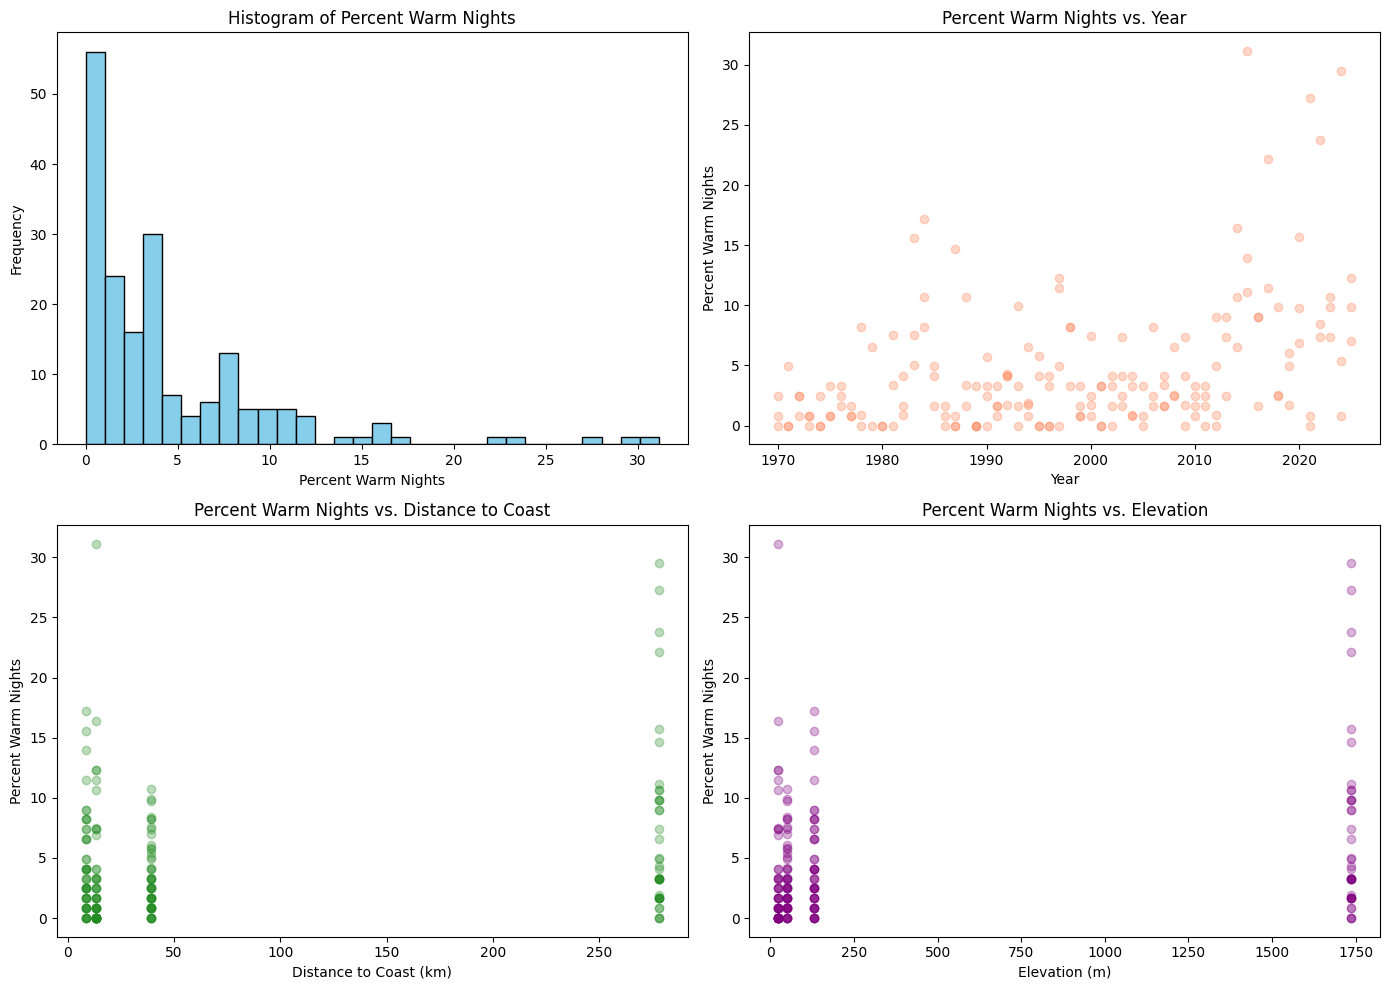

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# 1. Histogram of percent_warm_nights
plt.subplot(2, 2, 1)
plt.hist(filtered_dataset['percent_warm_nights'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Percent Warm Nights')
plt.xlabel('Percent Warm Nights')
plt.ylabel('Frequency')

# 2. Scatterplot: percent_warm_nights vs year
plt.subplot(2, 2, 2)
plt.scatter(filtered_dataset['year'], filtered_dataset['percent_warm_nights'], alpha=0.3, color='coral')
plt.title('Percent Warm Nights vs. Year')
plt.xlabel('Year')
plt.ylabel('Percent Warm Nights')

# 3. Scatterplot: percent_warm_nights vs distance_to_coast_km
plt.subplot(2, 2, 3)
plt.scatter(filtered_dataset['distance_to_coast_km'], filtered_dataset['percent_warm_nights'], alpha=0.3, color='forestgreen')
plt.title('Percent Warm Nights vs. Distance to Coast')
plt.xlabel('Distance to Coast (km)')
plt.ylabel('Percent Warm Nights')

# 4. Scatterplot: percent_warm_nights vs elevation_m
plt.subplot(2, 2, 4)
plt.scatter(filtered_dataset['elevation'], filtered_dataset['percent_warm_nights'], alpha=0.3, color='purple')
plt.title('Percent Warm Nights vs. Elevation')
plt.xlabel('Elevation (m)')
plt.ylabel('Percent Warm Nights')

plt.tight_layout()
plt.show()